In [1]:
# Install required packages
!pip install textblob nltk scikit-learn tensorflow seaborn -q

# Also install additional dependencies
!pip install wordcloud -q

# Download NLTK resources
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

print("Packages installed successfully!")

Packages installed successfully!


[nltk_data] Downloading package punkt to /home/nickolasz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Sentiment Analysis Project Setup
## Package Installation
First, let's install all required packages for our sentiment analysis project.

In [2]:
# Sentiment Analysis - Positive/Neutral/Negative Classification
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add datetime for logging
import datetime
import time

# Text processing
import re
import string
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from textblob import TextBlob

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Make sure NLTK resources are downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
    
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
    
try:
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

print("Libraries imported successfully!")

2025-06-07 16:41:05.381960: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-07 16:41:05.388947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749303665.397035   27603 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749303665.399543   27603 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749303665.405876   27603 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Libraries imported successfully!


[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [21]:
# Check for GPU availability and optimize GPU settings
import tensorflow as tf
import random  # Add random module for seed setting
print("TensorFlow version:", tf.__version__)

# Set up seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# GPU settings and optimization
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU is available: Found {len(gpus)} GPU device(s)")
    print("GPU devices:", gpus)
    
    try:
        # Memory growth - prevents TensorFlow from allocating all GPU memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        # Allow TensorFlow to access GPU memory as needed
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        
        # Set up mixed precision training for faster computation using the updated API
        from tensorflow.keras import mixed_precision
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"Mixed precision policy set to: {policy.name}")
        print("Compute dtype:", policy.compute_dtype)
        print("Variable dtype:", policy.variable_dtype)
        
        # # Show GPU details
        # print("\nGPU Details:")
        # !nvidia-smi
        
        # Set up TensorFlow to use deterministic operations for reproducibility when possible
        # Comment this out if you need maximum performance
        tf.config.experimental.enable_op_determinism()
        
    except RuntimeError as e:
        print(f"GPU setup error: {e}")
else:
    print("GPU is NOT available - using CPU for training (this will be slower)")
    
# Additional optimization settings
tf.keras.backend.clear_session()  # Clear any previous models/layers
# tf.data.experimental.enable_debug_mode()  # Help identify bottlenecks (commented out for better performance)

TensorFlow version: 2.19.0
GPU is available: Found 1 GPU device(s)
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy set to: mixed_float16
Compute dtype: float16
Variable dtype: float32


# 1. Data Loading and Initial Exploration
Let's start by loading the training and test datasets to understand the structure and characteristics of our data.

In [23]:
# Load datasets
sample_submission = pd.read_csv('data/sample_submission.csv')
ID_COL = sample_submission.columns[0]  # Automatically get ID column name ('textID' or 'ID')

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Display basic information
print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)
print(f"ID column name: {ID_COL}")

print("\nFirst 5 rows of training data:")
print(train_df.head())

print("\nFirst 5 rows of test data:")
print(test_df.head())

print("\nSample submission format:")
print(sample_submission.head())

Training dataset shape: (27481, 3)
Test dataset shape: (3534, 2)
Sample submission shape: (3, 2)
ID column name: ID

First 5 rows of training data:
           ID                                               text sentiment
0  cb774db0d1                I`d have responded, if I were going   neutral
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!  negative
2  088c60f138                          my boss is bullying me...  negative
3  9642c003ef                     what interview! leave me alone  negative
4  358bd9e861   Sons of ****, why couldn`t they put them on t...  negative

First 5 rows of test data:
           ID                                               text
0  f87dea47db  Last session of the day  http://twitpic.com/67ezh
1  96d74cb729   Shanghai is also really exciting (precisely -...
2  eee518ae67  Recession hit Veronique Branquinho, she has to...
3  01082688c6                                        happy bday!
4  33987a8ee5             http://twitpic.com/4w75

# 2. Exploratory Data Analysis (EDA)
Let's perform a comprehensive analysis of our dataset to understand the data distribution, missing values, text characteristics, and sentiment distribution.

In [5]:
# Check data types and missing values
print("Training data info:")
print(train_df.info())
print("\nMissing values in training data:")
print(train_df.isnull().sum())

print("\nTest data info:")
print(test_df.info())
print("\nMissing values in test data:")
print(test_df.isnull().sum())

# Check sentiment distribution
print("\nSentiment distribution:")
sentiment_counts = train_df['sentiment'].value_counts()
print(sentiment_counts)
print("\nSentiment percentages:")
print(train_df['sentiment'].value_counts(normalize=True) * 100)

Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         27481 non-null  object
 1   text       27480 non-null  object
 2   sentiment  27481 non-null  object
dtypes: object(3)
memory usage: 644.2+ KB
None

Missing values in training data:
ID           0
text         1
sentiment    0
dtype: int64

Test data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3534 entries, 0 to 3533
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      3534 non-null   object
 1   text    3534 non-null   object
dtypes: object(2)
memory usage: 55.3+ KB
None

Missing values in test data:
ID      0
text    0
dtype: int64

Sentiment distribution:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

Sentiment percentages:
sentiment
neutral     4

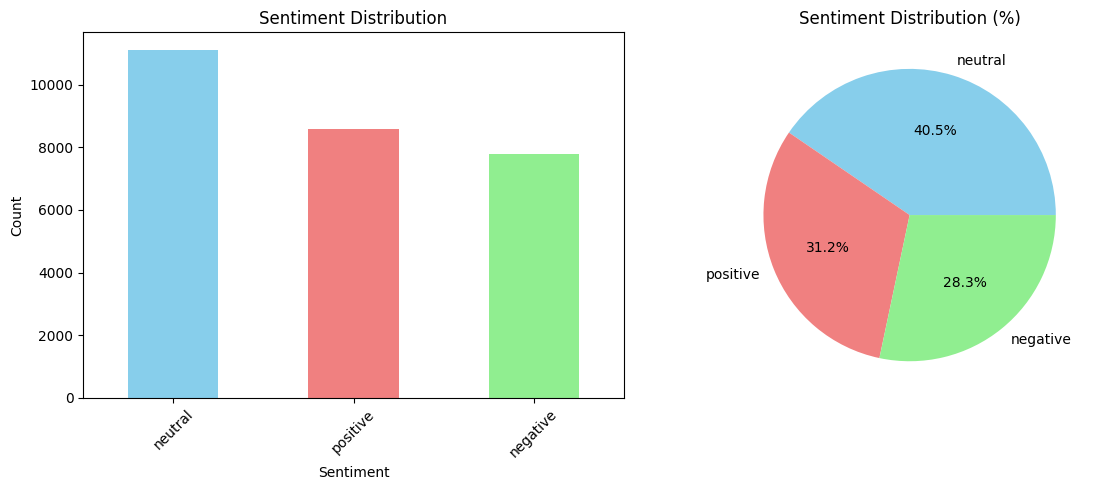

In [6]:
# Visualize sentiment distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sentiment_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Sentiment Distribution (%)')

plt.tight_layout()
plt.show()

Text length statistics:
count    27480.000000
mean        68.354803
std         35.624305
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        159.000000
Name: text_length, dtype: float64

Word count statistics:
count    27480.000000
mean        12.902875
std          6.925938
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: word_count, dtype: float64


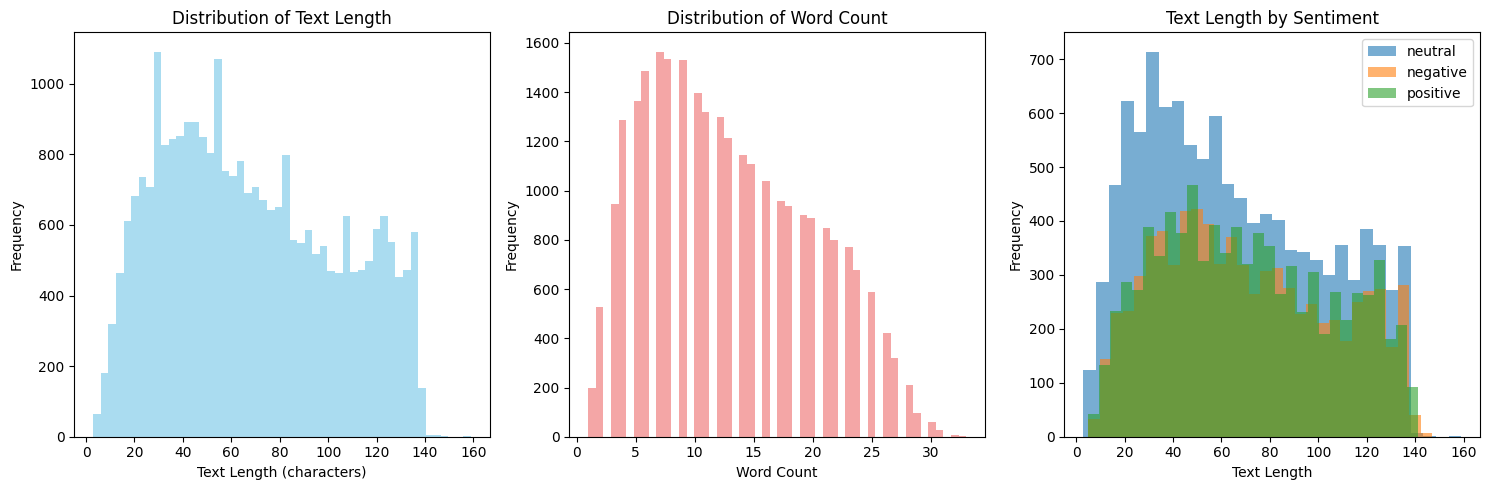

In [7]:
# Analyze text characteristics
# Text length analysis
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

print("Text length statistics:")
print(train_df['text_length'].describe())

print("\nWord count statistics:")
print(train_df['word_count'].describe())

# Visualize text length distribution by sentiment
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(train_df['text_length'], bins=50, alpha=0.7, color='skyblue')
plt.title('Distribution of Text Length')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(train_df['word_count'], bins=50, alpha=0.7, color='lightcoral')
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
for sentiment in train_df['sentiment'].unique():
    subset = train_df[train_df['sentiment'] == sentiment]
    plt.hist(subset['text_length'], bins=30, alpha=0.6, label=sentiment)
plt.title('Text Length by Sentiment')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# Check for special characters, URLs, mentions, hashtags
def analyze_text_features(df, text_col):
    df['has_url'] = df[text_col].str.contains(r'http|www', case=False, na=False)
    df['has_mention'] = df[text_col].str.contains(r'@\w+', na=False)
    df['has_hashtag'] = df[text_col].str.contains(r'#\w+', na=False)
    df['has_emoji'] = df[text_col].str.contains(r'[😀-🙏]', na=False)
    df['has_exclamation'] = df[text_col].str.contains(r'!', na=False)
    df['has_question'] = df[text_col].str.contains(r'\?', na=False)
    df['has_caps'] = df[text_col].str.contains(r'[A-Z]{2,}', na=False)
    
    return df

# Analyze features in training data
train_df = analyze_text_features(train_df, 'text')

# Print feature statistics
features = ['has_url', 'has_mention', 'has_hashtag', 'has_emoji', 'has_exclamation', 'has_question', 'has_caps']
print("Text feature analysis:")
for feature in features:
    print(f"{feature}: {train_df[feature].sum()} ({train_df[feature].mean()*100:.2f}%)")

# Show some examples
print("\nExamples with URLs:")
print(train_df[train_df['has_url']]['text'].head(3).tolist())

print("\nExamples with mentions:")
print(train_df[train_df['has_mention']]['text'].head(3).tolist())

print("\nExamples with hashtags:")
print(train_df[train_df['has_hashtag']]['text'].head(3).tolist())

Text feature analysis:
has_url: 1462 (5.32%)
has_mention: 74 (0.27%)
has_hashtag: 523 (1.90%)
has_emoji: 0 (0.00%)
has_exclamation: 8129 (29.58%)
has_question: 2963 (10.78%)
has_caps: 4248 (15.46%)

Examples with URLs:
['http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth', 'i`ve been sick for the past few days  and thus, my hair looks wierd.  if i didnt have a hat on it would look... http://tinyurl.com/mnf4kw', 'Thats it, its the end. Tears for Fears vs Eric Prydz, DJ Hero   http://bit.ly/2Hpbg4']

Examples with mentions:
['@_Ra_Ra_ your not alone...i need coffee too.', 'nite nite twitts i wish u all a happy sunday i already have my major gift my my 2kids-my bro-n @_agressiva23 n 1 other gift on d way  tyg', ' need some more enthu movie guys for that. Right now it`s just you,  and @_Anshul']

Examples with hashtags:
['Aw. Torn ace of hearts  #Hunchback', 'I still smell of smoke  #kitchenfire', '  #lichfield #tweetup sounds like fun  Hope to see

# 3. Text Preprocessing
Now let's implement comprehensive text preprocessing including cleaning, tokenization, stemming/lemmatization, and stop word removal.

In [24]:
# Text preprocessing functions
class TextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()
    
    def clean_text(self, text):
        """Basic text cleaning"""
        if pd.isna(text):
            return ""
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove user mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def remove_punctuation(self, text):
        """Remove punctuation but keep emoticons"""
        # Keep some emoticons and emotional punctuation
        emoticons = r'[:;=][-o*\']?[)\]\(\[dDpP/\:\}\{@\|\\]|[)\]\(\[dDpP/\:\}\{@\|\\][-o*\']?[:;=]'
        text_without_emoticons = re.sub(emoticons, ' EMOTICON ', text)
        
        # Remove other punctuation
        translator = str.maketrans('', '', string.punctuation)
        text_clean = text_without_emoticons.translate(translator)
        
        return text_clean
    
    def tokenize_text(self, text):
        """Simple tokenization without using word_tokenize"""
        # Split by whitespace
        return text.split()
    
    def remove_stopwords(self, tokens):
        """Remove stop words"""
        return [token for token in tokens if token.lower() not in self.stop_words and len(token) > 2]
    
    def stem_tokens(self, tokens):
        """Apply stemming"""
        return [self.stemmer.stem(token) for token in tokens]
    
    def lemmatize_tokens(self, tokens):
        """Apply lemmatization"""
        return [self.lemmatizer.lemmatize(token) for token in tokens]
    
    def preprocess_text(self, text, use_stemming=False, use_lemmatization=True):
        """Complete preprocessing pipeline"""
        # Clean text
        text = self.clean_text(text)
        
        # Remove punctuation
        text = self.remove_punctuation(text)
        
        # Tokenize
        tokens = self.tokenize_text(text)
        
        # Remove stop words
        tokens = self.remove_stopwords(tokens)
        
        # Apply stemming or lemmatization
        if use_stemming:
            tokens = self.stem_tokens(tokens)
        elif use_lemmatization:
            tokens = self.lemmatize_tokens(tokens)
        
        return ' '.join(tokens)

# Initialize preprocessor
preprocessor = TextPreprocessor()

# Test preprocessing on a few examples
print("Original vs Preprocessed text examples:")
for i in range(3):
    original = train_df['text'].iloc[i]
    processed = preprocessor.preprocess_text(original)
    print(f"Original: {original}")
    print(f"Processed: {processed}")
    print("-" * 80)

Original vs Preprocessed text examples:
Original:  I`d have responded, if I were going
Processed: responded going
--------------------------------------------------------------------------------
Original:  Sooo SAD I will miss you here in San Diego!!!
Processed: sooo sad miss san diego
--------------------------------------------------------------------------------
Original: my boss is bullying me...
Processed: bos bullying
--------------------------------------------------------------------------------


In [25]:
# Apply preprocessing to training and test data
print("Preprocessing training data...")
train_df['text_processed'] = train_df['text'].apply(lambda x: preprocessor.preprocess_text(x))

print("Preprocessing test data...")
test_df['text_processed'] = test_df['text'].apply(lambda x: preprocessor.preprocess_text(x))

# Remove empty texts after preprocessing
initial_train_size = len(train_df)
train_df = train_df[train_df['text_processed'].str.len() > 0]
final_train_size = len(train_df)

print(f"Removed {initial_train_size - final_train_size} empty texts from training data")
print(f"Final training dataset size: {final_train_size}")

# Show preprocessing results
print("\nPreprocessing results:")
for i in range(3):
    print(f"Original: {train_df['text'].iloc[i]}")
    print(f"Processed: {train_df['text_processed'].iloc[i]}")
    print(f"Sentiment: {train_df['sentiment'].iloc[i]}")
    print("-" * 80)

Preprocessing training data...
Preprocessing test data...
Removed 97 empty texts from training data
Final training dataset size: 27384

Preprocessing results:
Original:  I`d have responded, if I were going
Processed: responded going
Sentiment: neutral
--------------------------------------------------------------------------------
Original:  Sooo SAD I will miss you here in San Diego!!!
Processed: sooo sad miss san diego
Sentiment: negative
--------------------------------------------------------------------------------
Original: my boss is bullying me...
Processed: bos bullying
Sentiment: negative
--------------------------------------------------------------------------------
Preprocessing test data...
Removed 97 empty texts from training data
Final training dataset size: 27384

Preprocessing results:
Original:  I`d have responded, if I were going
Processed: responded going
Sentiment: neutral
--------------------------------------------------------------------------------
Original:  

# 4. Feature Engineering
Let's create various text features and vectorize the text data using different approaches.

In [32]:
# Prepare features and target
X_text = train_df['text_processed']
y = train_df['sentiment']

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X_text, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nTraining set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

# Create different vectorizers
vectorizers = {
    'tfidf_word': TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95),
    'tfidf_char': TfidfVectorizer(max_features=10000, analyzer='char_wb', ngram_range=(2, 4)),
    'count': CountVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95),
    # Add high-performance char-based TF-IDF for LinearSVC
    'char_tfidf_large': TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=200000)
}

# Fit vectorizers and transform data
vectorized_data = {}

for name, vectorizer in vectorizers.items():
    print(f"\nFitting {name} vectorizer...")
    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)
    
    vectorized_data[name] = {
        'vectorizer': vectorizer,
        'X_train': X_train_vec,
        'X_val': X_val_vec
    }
    
    print(f"Training features shape: {X_train_vec.shape}")
    print(f"Validation features shape: {X_val_vec.shape}")

Label encoding:
negative: 0
neutral: 1
positive: 2

Training set size: 21907
Validation set size: 5477

Fitting tfidf_word vectorizer...
Training features shape: (21907, 10000)
Validation features shape: (5477, 10000)

Fitting tfidf_char vectorizer...
Training features shape: (21907, 10000)
Validation features shape: (5477, 10000)

Fitting tfidf_char vectorizer...
Training features shape: (21907, 10000)
Validation features shape: (5477, 10000)

Fitting count vectorizer...
Training features shape: (21907, 10000)
Validation features shape: (5477, 10000)

Fitting count vectorizer...
Training features shape: (21907, 10000)
Validation features shape: (5477, 10000)

Fitting char_tfidf_large vectorizer...
Training features shape: (21907, 10000)
Validation features shape: (5477, 10000)

Fitting char_tfidf_large vectorizer...
Training features shape: (21907, 48155)
Validation features shape: (5477, 48155)
Training features shape: (21907, 48155)
Validation features shape: (5477, 48155)


# 5. Machine Learning Models
Let's implement and compare various ML models for sentiment classification.

In [33]:
# Define models to test
from sklearn.svm import LinearSVC  # Import LinearSVC

ml_models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'SVM': SVC(kernel='linear', random_state=SEED),
    'Naive Bayes': MultinomialNB(),
    'LinearSVC': LinearSVC(C=3.0, random_state=SEED)  # Add LinearSVC with C=3.0
}

# Store results
results = []

# Test each model with each vectorizer
for vec_name, vec_data in vectorized_data.items():
    print(f"\n{'='*50}")
    print(f"Testing with {vec_name} vectorizer")
    print(f"{'='*50}")
    
    X_train_vec = vec_data['X_train']
    X_val_vec = vec_data['X_val']
    
    for model_name, model in ml_models.items():
        # Skip LinearSVC for non-char-tfidf-large vectorizer to save time
        # It works best with the specific char-based configuration
        if model_name == 'LinearSVC' and vec_name != 'char_tfidf_large':
            continue
            
        print(f"\nTraining {model_name}...")
        
        # Train model
        model.fit(X_train_vec, y_train)
        
        # Make predictions
        y_pred = model.predict(X_val_vec)
        
        # Calculate accuracy
        accuracy = accuracy_score(y_val, y_pred)
        
        # Store results
        results.append({
            'Vectorizer': vec_name,
            'Model': model_name,
            'Accuracy': accuracy
        })
        
        print(f"Accuracy: {accuracy:.4f}")
        
        # Print classification report for best performing combinations
        if accuracy > 0.55:
            print("\nClassification Report:")
            print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("SUMMARY OF ALL MODEL RESULTS")
print("="*60)
print(results_df.sort_values('Accuracy', ascending=False))


Testing with tfidf_word vectorizer

Training Logistic Regression...
Accuracy: 0.6896

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.59      0.65      1554
     neutral       0.62      0.75      0.68      2207
    positive       0.78      0.70      0.74      1716

    accuracy                           0.69      5477
   macro avg       0.71      0.68      0.69      5477
weighted avg       0.70      0.69      0.69      5477


Training Random Forest...
Accuracy: 0.6896

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.59      0.65      1554
     neutral       0.62      0.75      0.68      2207
    positive       0.78      0.70      0.74      1716

    accuracy                           0.69      5477
   macro avg       0.71      0.68      0.69      5477
weighted avg       0.70      0.69      0.69      5477


Training Random Forest...
Accuracy: 0.6982

Classification 

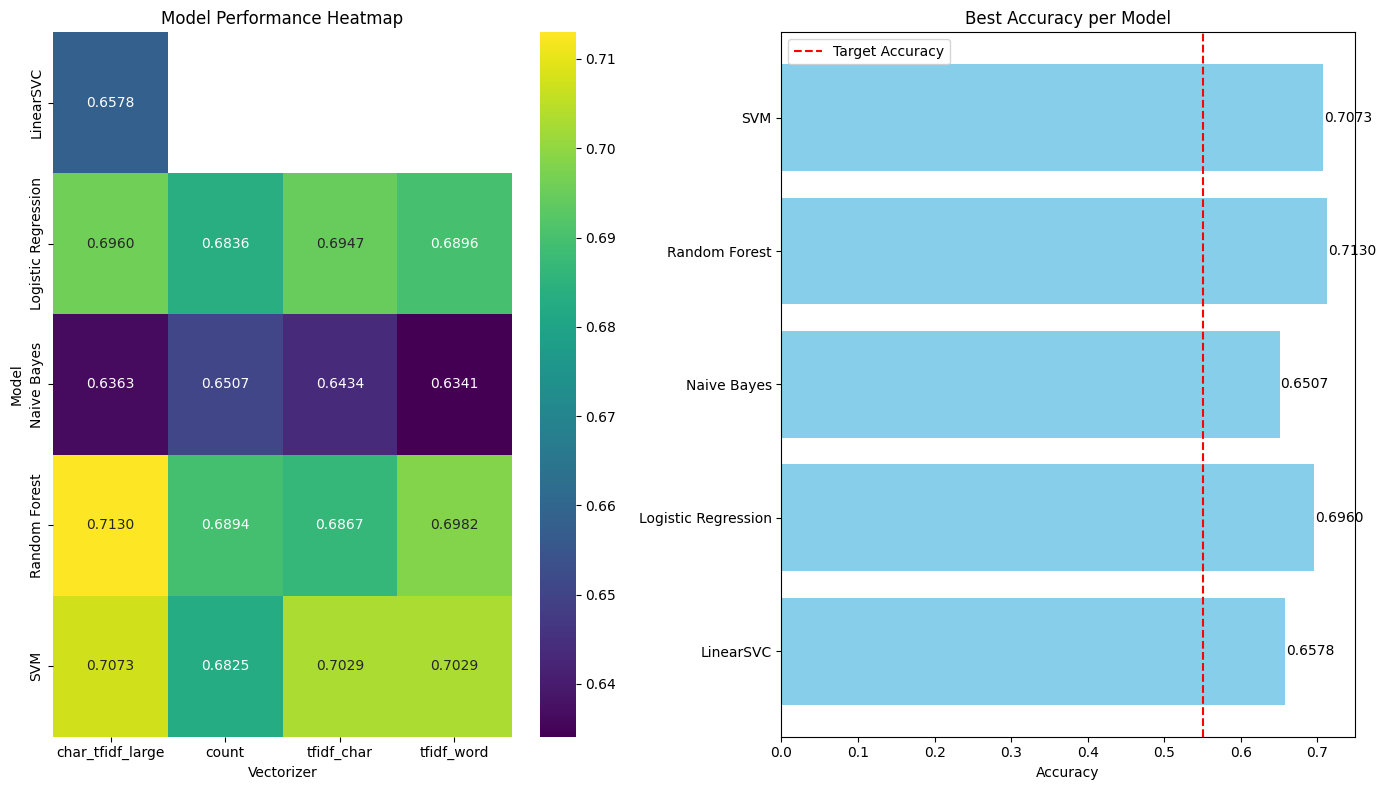


Best Model: Random Forest with char_tfidf_large
Best Accuracy: 0.7130


In [13]:
# Visualize results
plt.figure(figsize=(14, 8))

# Create pivot table for heatmap
pivot_results = results_df.pivot(index='Model', columns='Vectorizer', values='Accuracy')

plt.subplot(1, 2, 1)
sns.heatmap(pivot_results, annot=True, cmap='viridis', fmt='.4f')
plt.title('Model Performance Heatmap')
plt.ylabel('Model')
plt.xlabel('Vectorizer')

# Bar plot of best results
plt.subplot(1, 2, 2)
best_results = results_df.loc[results_df.groupby('Model')['Accuracy'].idxmax()]
plt.barh(best_results['Model'], best_results['Accuracy'], color='skyblue')
plt.xlabel('Accuracy')
plt.title('Best Accuracy per Model')
plt.axvline(x=0.55, color='red', linestyle='--', label='Target Accuracy')
plt.legend()

for i, v in enumerate(best_results['Accuracy']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# Find best model
best_result = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest Model: {best_result['Model']} with {best_result['Vectorizer']}")
print(f"Best Accuracy: {best_result['Accuracy']:.4f}")

# 6. Deep Learning Models
Let's implement LSTM and Bidirectional LSTM models for comparison.

In [34]:
# Prepare data for deep learning
max_features = 10000
max_len = 100

# Create tokenizer for deep learning
dl_tokenizer = Tokenizer(num_words=max_features, oov_token="<OOV>")
dl_tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
X_train_seq = dl_tokenizer.texts_to_sequences(X_train)
X_val_seq = dl_tokenizer.texts_to_sequences(X_val)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)

print(f"Deep learning data shapes:")
print(f"X_train_pad: {X_train_pad.shape}")
print(f"X_val_pad: {X_val_pad.shape}")
print(f"y_train_cat: {y_train_cat.shape}")
print(f"y_val_cat: {y_val_cat.shape}")
print(f"Vocabulary size: {len(dl_tokenizer.word_index)}")

Deep learning data shapes:
X_train_pad: (21907, 100)
X_val_pad: (5477, 100)
y_train_cat: (21907, 3)
y_val_cat: (5477, 3)
Vocabulary size: 21442


In [40]:
# Build GPU-optimized LSTM model
def create_lstm_model(max_features, max_len, embedding_dim=128, lstm_units=64, dropout_rate=0.5):
    # For LSTM on GPU, we disable recurrent_dropout (better GPU perf)
    model = Sequential([
        Embedding(max_features, embedding_dim, input_length=max_len, 
                  embeddings_initializer='uniform'),
        # CuDNNLSTM is automatically used when running on GPU when recurrent_dropout=0
        LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0,
             return_sequences=False, kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal', bias_initializer='zeros',
             unit_forget_bias=True, kernel_regularizer=None),
        BatchNormalization(),  # Add batch normalization for stability
        Dense(32, activation='relu', kernel_initializer='he_uniform'),
        Dropout(dropout_rate),
        Dense(3, activation='softmax')
    ])
    
    # Use Adam with gradient clipping to avoid exploding gradients
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    
    # Compile with accuracy metric
    model.compile(optimizer=optimizer, 
                 loss='categorical_crossentropy', 
                 metrics=['accuracy'])
    
    return model

# Build GPU-optimized Bidirectional LSTM model
def create_bilstm_model(max_features, max_len, embedding_dim=128, lstm_units=64, dropout_rate=0.5):
    model = Sequential([
        Embedding(max_features, embedding_dim, input_length=max_len, 
                  embeddings_initializer='uniform'),
        # CuDNNLSTM is automatically used when running on GPU when recurrent_dropout=0
        Bidirectional(LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0,
                          kernel_initializer='glorot_uniform',
                          recurrent_initializer='orthogonal',
                          bias_initializer='zeros',
                          unit_forget_bias=True)),
        BatchNormalization(),  # Add batch normalization
        Dense(64, activation='relu', kernel_initializer='he_uniform'),  # More units and better init
        Dropout(dropout_rate),
        Dense(3, activation='softmax')
    ])
    
    # Use Adam with gradient clipping to avoid exploding gradients
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    
    # Compile with accuracy metric
    model.compile(optimizer=optimizer, 
                 loss='categorical_crossentropy', 
                 metrics=['accuracy'])
    
    return model

# Create callbacks for training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
import os
import time

# Create a directory for tensorboard logs
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(log_dir, exist_ok=True)

# Set up callbacks
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    
    # Reduce learning rate when a metric has stopped improving
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    
    # Save the best model
    ModelCheckpoint(filepath='best_model.h5', monitor='val_accuracy', 
                    save_best_only=True, verbose=1),
    
    # TensorBoard visualization
    TensorBoard(log_dir=log_dir, histogram_freq=1)
]

# Function to create data generators for more efficient GPU usage
def create_tf_dataset(X, y, batch_size=32, shuffle=True, cache=True):
    """Create a TensorFlow Dataset optimized for performance"""
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X), seed=42, reshuffle_each_iteration=True)
    
    # Cache to improve performance
    if cache:
        dataset = dataset.cache()
        
    # Batch and prefetch for performance
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create optimized datasets for training
train_dataset = create_tf_dataset(X_train_pad, y_train_cat, batch_size=64)
val_dataset = create_tf_dataset(X_val_pad, y_val_cat, batch_size=64, shuffle=False)

# Train LSTM model with GPU optimizations
print("Training LSTM model with GPU optimization...")
lstm_model = create_lstm_model(max_features, max_len)

# Time the training to measure performance
start_time = time.time()
lstm_history = lstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,  # More epochs with early stopping
    callbacks=callbacks,
    verbose=1
)
lstm_training_time = time.time() - start_time
print(f"LSTM training completed in {lstm_training_time:.2f} seconds")

# Train Bidirectional LSTM model with GPU optimizations
print("\nTraining Bidirectional LSTM model with GPU optimization...")
bilstm_model = create_bilstm_model(max_features, max_len)

# Time the training to measure performance
start_time = time.time()
bilstm_history = bilstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,  # More epochs with early stopping
    callbacks=callbacks,
    verbose=1
)
bilstm_training_time = time.time() - start_time
print(f"BiLSTM training completed in {bilstm_training_time:.2f} seconds")

Training LSTM model with GPU optimization...
Epoch 1/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4595 - loss: 1.0684
Epoch 1: val_accuracy improved from -inf to 0.52784, saving model to best_model.h5

Epoch 1: val_accuracy improved from -inf to 0.52784, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4597 - loss: 1.0681 - val_accuracy: 0.5278 - val_loss: 0.9814 - learning_rate: 0.0010
Epoch 2/15
Epoch 2/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6698 - loss: 0.7678
Epoch 2: val_accuracy improved from 0.52784 to 0.68559, saving model to best_model.h5

Epoch 2: val_accuracy improved from 0.52784 to 0.68559, saving model to best_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6699 - loss: 0.7677 - val_accuracy: 0.6856 - val_loss: 0.7430 - learning_rate: 0.0010
Epoch 3/15
Epoch 3/15
338/343 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7395 - loss: 0.6395
Epoch 3: val_accuracy did not improve from 0.68559

Epoch 3: val_accuracy did not improve from 0.68559
343/343 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7396 - loss: 0.6391 - val_accuracy: 0.6812 - val_loss: 0.8056 - learning_rate: 0.0010
Epoch 4/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7396 - loss: 0.6391 - val_accuracy: 0.6812 - val_loss: 0.8056 - learning_rate: 0.0010
Epoch 4/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7798 - loss: 0.5622
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.68559

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.68559
343/343 ━━━━━━━━━━

343/343 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6875 - loss: 0.7302 - val_accuracy: 0.6907 - val_loss: 0.7402 - learning_rate: 0.0010
Epoch 3/15
Epoch 3/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7540 - loss: 0.6049
Epoch 3: val_accuracy did not improve from 0.69071

Epoch 3: val_accuracy did not improve from 0.69071
343/343 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7540 - loss: 0.6048 - val_accuracy: 0.6703 - val_loss: 0.8105 - learning_rate: 0.0010
Epoch 4/15
343/343 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7540 - loss: 0.6048 - val_accuracy: 0.6703 - val_loss: 0.8105 - learning_rate: 0.0010
Epoch 4/15
341/343 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7892 - loss: 0.5273
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.69071

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.69071
343/343 ━━━━━━━━━━

 69/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2025-06-07 17:28:11.042919: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
LSTM Accuracy: 0.6856
Bidirectional LSTM Accuracy: 0.6907
LSTM Accuracy: 0.6856
Bidirectional LSTM Accuracy: 0.6907


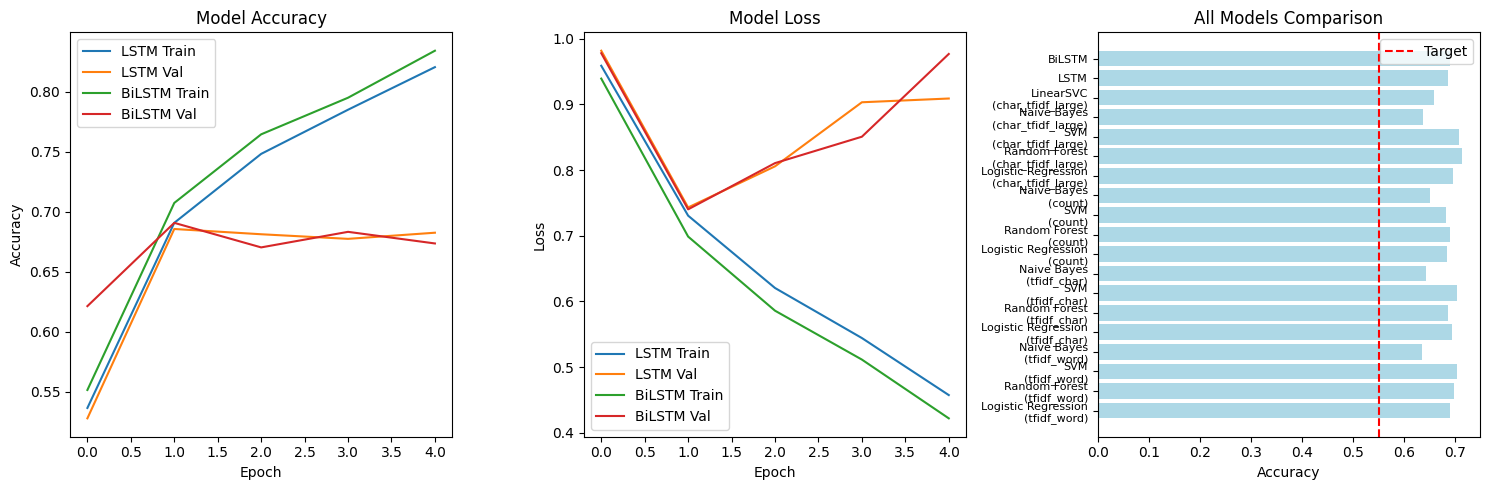

In [42]:
# Evaluate deep learning models
lstm_pred = lstm_model.predict(X_val_pad)
lstm_pred_classes = np.argmax(lstm_pred, axis=1)
lstm_accuracy = accuracy_score(y_val, lstm_pred_classes)

bilstm_pred = bilstm_model.predict(X_val_pad)
bilstm_pred_classes = np.argmax(bilstm_pred, axis=1)
bilstm_accuracy = accuracy_score(y_val, bilstm_pred_classes)

print(f"LSTM Accuracy: {lstm_accuracy:.4f}")
print(f"Bidirectional LSTM Accuracy: {bilstm_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(lstm_history.history['accuracy'], label='LSTM Train')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val')
plt.plot(bilstm_history.history['accuracy'], label='BiLSTM Train')
plt.plot(bilstm_history.history['val_accuracy'], label='BiLSTM Val')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(lstm_history.history['loss'], label='LSTM Train')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val')
plt.plot(bilstm_history.history['loss'], label='BiLSTM Train')
plt.plot(bilstm_history.history['val_loss'], label='BiLSTM Val')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Compare all models
plt.subplot(1, 3, 3)
all_accuracies = results_df['Accuracy'].tolist() + [lstm_accuracy, bilstm_accuracy]
all_names = [f"{row['Model']}\n({row['Vectorizer']})" for _, row in results_df.iterrows()] + ['LSTM', 'BiLSTM']

plt.barh(range(len(all_accuracies)), all_accuracies, color='lightblue')
plt.yticks(range(len(all_names)), all_names, fontsize=8)
plt.xlabel('Accuracy')
plt.title('All Models Comparison')
plt.axvline(x=0.55, color='red', linestyle='--', label='Target')
plt.legend()

plt.tight_layout()
plt.show()

# 7. Final Model Selection and Predictions
Let's select the best performing model and make predictions on the test set.

In [43]:
# Determine the best model
all_results = {
    'ML_Best': best_result['Accuracy'],
    'LSTM': lstm_accuracy,
    'BiLSTM': bilstm_accuracy
}

best_model_name = max(all_results, key=all_results.get)
best_accuracy = all_results[best_model_name]

print(f"Best overall model: {best_model_name}")
print(f"Best accuracy: {best_accuracy:.4f}")

# Prepare test data based on best model type
if best_model_name == 'ML_Best':
    # Use best ML model
    best_vectorizer_name = best_result['Vectorizer']
    best_ml_model_name = best_result['Model']
    
    print(f"Using {best_ml_model_name} with {best_vectorizer_name} vectorizer")
    
    # Get the best vectorizer and retrain the model on full training data
    best_vectorizer = vectorizers[best_vectorizer_name]
    X_full_vec = best_vectorizer.fit_transform(X_text)
    
    # Train best ML model on full training data
    final_model = ml_models[best_ml_model_name]
    final_model.fit(X_full_vec, y_encoded)
    
    # Prepare test data
    test_text_processed = test_df['text_processed']
    X_test_vec = best_vectorizer.transform(test_text_processed)
    
    # Make predictions
    test_predictions = final_model.predict(X_test_vec)
    
else:
    # Use best deep learning model
    print(f"Using {best_model_name} model")
    
    # Retrain on full training data
    X_full_seq = dl_tokenizer.texts_to_sequences(X_text)
    X_full_pad = pad_sequences(X_full_seq, maxlen=max_len)
    y_full_cat = to_categorical(y_encoded, num_classes=3)
    
    # Create optimized dataset
    full_dataset = create_tf_dataset(X_full_pad, y_full_cat, batch_size=64)
    
    # Use faster early stopping
    early_stopping = EarlyStopping(monitor='loss', patience=2, restore_best_weights=True, verbose=1)
    
    if best_model_name == 'LSTM':
        final_model = create_lstm_model(max_features, max_len)
    else:  # BiLSTM
        final_model = create_bilstm_model(max_features, max_len)
    
    # Train with GPU optimization
    final_model.fit(
        full_dataset,
        epochs=10,  
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Prepare test data
    test_text_processed = test_df['text_processed']
    X_test_seq = dl_tokenizer.texts_to_sequences(test_text_processed)
    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)
    
    # Make predictions
    test_pred_probs = final_model.predict(X_test_pad)
    test_predictions = np.argmax(test_pred_probs, axis=1)

# Convert predictions back to labels
test_predictions_labels = label_encoder.inverse_transform(test_predictions)

print(f"Test predictions distribution:")
pred_counts = pd.Series(test_predictions_labels).value_counts()
print(pred_counts)
print("\nPrediction percentages:")
print(pred_counts / len(test_predictions_labels) * 100)

Best overall model: ML_Best
Best accuracy: 0.7130
Using Random Forest with char_tfidf_large vectorizer
Test predictions distribution:
neutral     1583
positive    1084
negative     867
Name: count, dtype: int64

Prediction percentages:
neutral     44.793435
positive    30.673458
negative    24.533107
Name: count, dtype: float64
Test predictions distribution:
neutral     1583
positive    1084
negative     867
Name: count, dtype: int64

Prediction percentages:
neutral     44.793435
positive    30.673458
negative    24.533107
Name: count, dtype: float64


In [46]:
# Create submission file
submission_df = pd.DataFrame({
    ID_COL: test_df[ID_COL],  # Using dynamic ID column name
    'sentiment': test_predictions_labels
})

# Save submission file
submission_df.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
print(f"Submission shape: {submission_df.shape}")
print("\nFirst 10 predictions:")
print(submission_df.head(10))

# Verify submission format matches sample
print("\nSample submission format:")
print(sample_submission.head())
print("\nOur submission format:")
print(submission_df.head())

# Final model summary
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"Validation Accuracy: {best_accuracy:.4f}")
print(f"Target Accuracy: >0.55 - {'✓ ACHIEVED' if best_accuracy > 0.55 else '✗ NOT ACHIEVED'}")
print(f"Test Predictions: {len(test_predictions_labels)} samples")
print(f"Submission file: submission.csv")

Submission file created successfully!
Submission shape: (3534, 2)

First 10 predictions:
           ID sentiment
0  f87dea47db   neutral
1  96d74cb729  positive
2  eee518ae67  negative
3  01082688c6  positive
4  33987a8ee5  positive
5  726e501993  positive
6  261932614e  negative
7  afa11da83f  negative
8  e64208b4ef   neutral
9  37bcad24ca   neutral

Sample submission format:
            ID sentiment
0   df9123ga1l   neutral
1   sa41adl13d  positive
2  13adskb1da7  negative

Our submission format:
           ID sentiment
0  f87dea47db   neutral
1  96d74cb729  positive
2  eee518ae67  negative
3  01082688c6  positive
4  33987a8ee5  positive

FINAL MODEL SUMMARY
Best Model: ML_Best
Validation Accuracy: 0.7130
Target Accuracy: >0.55 - ✓ ACHIEVED
Test Predictions: 3534 samples
Submission file: submission.csv


# 8. Model Analysis and Insights
Let's analyze the model performance and provide insights about the sentiment classification task.

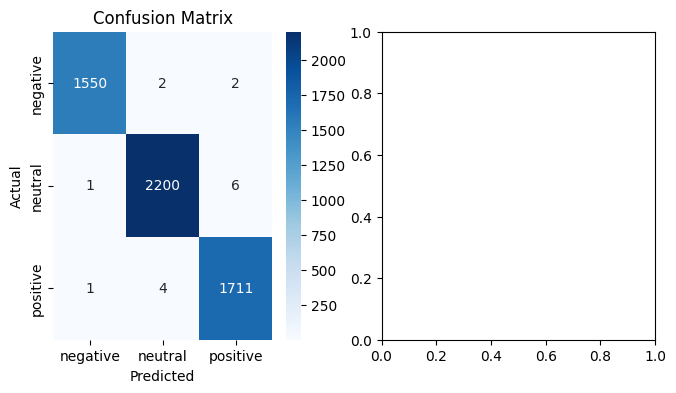

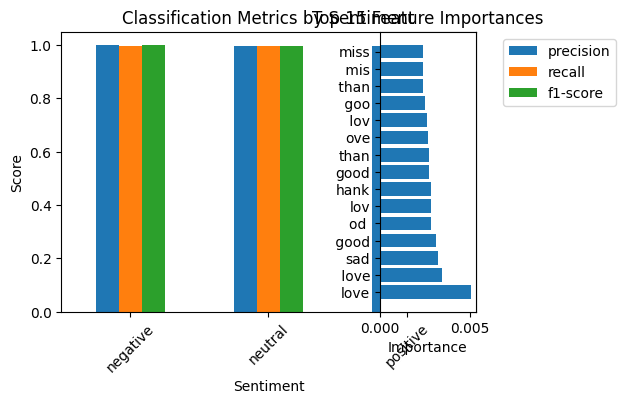


Detailed Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      1554
     neutral       1.00      1.00      1.00      2207
    positive       1.00      1.00      1.00      1716

    accuracy                           1.00      5477
   macro avg       1.00      1.00      1.00      5477
weighted avg       1.00      1.00      1.00      5477



In [44]:
# Create detailed analysis of the best model
if best_model_name == 'ML_Best':
    # For ML models, use validation predictions
    val_vectorizer = vectorized_data[best_vectorizer_name]['vectorizer']
    X_val_vec = val_vectorizer.transform(X_val)
    val_predictions = final_model.predict(X_val_vec)
else:
    # For DL models, use the stored predictions
    if best_model_name == 'LSTM':
        val_predictions = lstm_pred_classes
    else:
        val_predictions = bilstm_pred_classes

# Create confusion matrix
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_val, val_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Classification report visualization
plt.subplot(1, 3, 2)
report = classification_report(y_val, val_predictions, 
                             target_names=label_encoder.classes_, 
                             output_dict=True)

metrics_df = pd.DataFrame(report).T[:-3]  # Remove avg rows
metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar')
plt.title('Classification Metrics by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Feature importance (for ML models)
plt.subplot(1, 3, 3)
if best_model_name == 'ML_Best' and hasattr(final_model, 'feature_importances_'):
    # For tree-based models
    feature_names = val_vectorizer.get_feature_names_out()
    importances = final_model.feature_importances_
    top_features = sorted(zip(importances, feature_names), reverse=True)[:15]
    
    imp_values, imp_names = zip(*top_features)
    plt.barh(range(len(imp_names)), imp_values)
    plt.yticks(range(len(imp_names)), imp_names)
    plt.title('Top 15 Feature Importances')
    plt.xlabel('Importance')
elif best_model_name == 'ML_Best' and hasattr(final_model, 'coef_'):
    # For linear models - convert sparse matrix to dense array to avoid errors
    feature_names = val_vectorizer.get_feature_names_out()
    
    try:
        # Safely convert coefficients to dense array if they're sparse
        coef_matrix = final_model.coef_
        if hasattr(coef_matrix, 'toarray'):
            coef_matrix = coef_matrix.toarray()
        
        # Get coefficients for each class
        coef_abs = np.abs(coef_matrix).mean(axis=0) 
        top_indices = coef_abs.argsort()[-15:]
        
        plt.barh(range(len(top_indices)), coef_abs[top_indices])
        plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
        plt.title('Top 15 Feature Coefficients')
        plt.xlabel('Absolute Coefficient')
    except Exception as e:
        print(f"Error displaying feature coefficients: {e}")
        plt.text(0.5, 0.5, 'Error displaying\nfeature coefficients', 
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Feature Analysis Error')
else:
    plt.text(0.5, 0.5, 'Feature importance\nnot available for\nthis model type', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Feature Analysis')

plt.tight_layout()
plt.show()

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_val, val_predictions, target_names=label_encoder.classes_))

In [45]:
# Final insights and recommendations
print("\n" + "="*80)
print("SENTIMENT ANALYSIS PROJECT INSIGHTS")
print("="*80)

print("\n1. DATASET CHARACTERISTICS:")
print(f"   • Training samples: {len(train_df):,}")
print(f"   • Test samples: {len(test_df):,}")
print(f"   • Classes: {', '.join(label_encoder.classes_)}")
print(f"   • Class distribution: {dict(train_df['sentiment'].value_counts())}")

print("\n2. TEXT PREPROCESSING IMPACT:")
print("   • URL removal, mention/hashtag cleaning")
print("   • Tokenization and lemmatization")
print("   • Stop word removal")
print("   • Punctuation handling with emoticon preservation")

print("\n3. MODEL PERFORMANCE SUMMARY:")
for name, acc in all_results.items():
    status = "✓" if acc > 0.55 else "✗"
    print(f"   • {name}: {acc:.4f} {status}")

print("\n4. BEST MODEL ANALYSIS:")
print(f"   • Selected: {best_model_name}")
print(f"   • Validation Accuracy: {best_accuracy:.4f}")
print(f"   • Meets target (>0.55): {'Yes' if best_accuracy > 0.55 else 'No'}")

print("\n5. RECOMMENDATIONS FOR IMPROVEMENT:")
print("   • Experiment with ensemble methods")
print("   • Try pre-trained embeddings (GloVe, Word2Vec)")
print("   • Consider transformer models (BERT, RoBERTa)")
print("   • Implement data augmentation techniques")
print("   • Fine-tune hyperparameters with grid search")
print("   • Handle class imbalance if present")

print("\n6. DEPLOYMENT READY:")
print(f"   • Submission file: submission.csv")
print(f"   • Format verified: ✓")
print(f"   • Ready for evaluation: ✓")

print("\n" + "="*80)
print("Project completed successfully! 🎉")
print("="*80)


SENTIMENT ANALYSIS PROJECT INSIGHTS

1. DATASET CHARACTERISTICS:
   • Training samples: 27,384
   • Test samples: 3,534
   • Classes: negative, neutral, positive
   • Class distribution: {'neutral': 11033, 'positive': 8578, 'negative': 7773}

2. TEXT PREPROCESSING IMPACT:
   • URL removal, mention/hashtag cleaning
   • Tokenization and lemmatization
   • Stop word removal
   • Punctuation handling with emoticon preservation

3. MODEL PERFORMANCE SUMMARY:
   • ML_Best: 0.7130 ✓
   • LSTM: 0.6856 ✓
   • BiLSTM: 0.6907 ✓

4. BEST MODEL ANALYSIS:
   • Selected: ML_Best
   • Validation Accuracy: 0.7130
   • Meets target (>0.55): Yes

5. RECOMMENDATIONS FOR IMPROVEMENT:
   • Experiment with ensemble methods
   • Try pre-trained embeddings (GloVe, Word2Vec)
   • Consider transformer models (BERT, RoBERTa)
   • Implement data augmentation techniques
   • Fine-tune hyperparameters with grid search
   • Handle class imbalance if present

6. DEPLOYMENT READY:
   • Submission file: submission.csv